<a href="https://colab.research.google.com/github/shreyakiyoor/Keras/blob/master/CNN_Lesson_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Flatten,BatchNormalization,Conv2D,MaxPool2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy,binary_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.preprocessing import image


from sklearn.metrics import confusion_matrix

import glob
from google.colab import drive
import os
import random
import shutil

import matplotlib.pyplot as plt
import seaborn as sns


from io import BytesIO
from PIL import Image


import pandas as pd
import numpy as np
from tqdm import tqdm

In [32]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path = "/content/drive/MyDrive/Problems/CNN/Data/Sign-Language-Digits-Dataset"

In [ ]:
for dir in os.listdir(data_path):
  for file in os.listdir(os.path.join(data_path,dir)):

    if os.path.getsize(os.path.join(data_path,dir,file)) == 0:
      print(file)
      os.remove(os.path.join(data_path,file))



In [ ]:
if not os.path.exists(os.path.join(data_path,"train")):
  os.mkdir(os.path.join(data_path,"train"))
  os.mkdir(os.path.join(data_path,"test"))
  os.mkdir(os.path.join(data_path,"valid"))
  for i in range(10):
    os.mkdir(os.path.join(data_path,"train",str(i)))
    os.mkdir(os.path.join(data_path,"test",str(i)))
    os.mkdir(os.path.join(data_path,"valid",str(i)))
else:
  print("Directory already exists")

Directory already exists


In [ ]:
if not os.path.exists(os.path.join(data_path,"train")):
  for i in range(10):
    for file in random.sample(glob.glob(os.path.join(data_path,str(i),"*")),30):
      shutil.move(os.path.join(data_path,str(i),file),os.path.join(data_path,"valid",str(i)))
    for file in random.sample(glob.glob(os.path.join(data_path,str(i),"*")),5):
      shutil.move(os.path.join(data_path,str(i),file),os.path.join(data_path,"test",str(i)))

  for i in range(10):
    for file in glob.glob(os.path.join(data_path,str(i),"*")):
        shutil.move(os.path.join(data_path,str(i),file),os.path.join(data_path,"train",str(i)))
else:
  print("Directory already exists")

Directory already exists


In [ ]:
train_batches = ImageDataGenerator(preprocessing_function = tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(directory = os.path.join(data_path,"train"),target_size = (224,224),batch_size = 10)
test_batches = ImageDataGenerator(preprocessing_function = tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(directory = os.path.join(data_path,"test"),target_size = (224,224),batch_size = 10,shuffle = False)
valid_batches = ImageDataGenerator(preprocessing_function = tf.keras.applications.mobilenet.preprocess_input).flow_from_directory(directory = os.path.join(data_path,"valid"),target_size = (224,224),batch_size = 10)

Found 1712 images belonging to 10 classes.
Found 50 images belonging to 10 classes.
Found 300 images belonging to 10 classes.


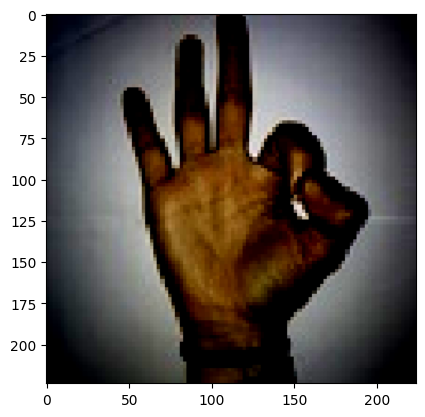

In [ ]:
plt.imshow(train_batches[15][0][0])

In [ ]:
mobile = tf.keras.applications.mobilenet.MobileNet()

In [ ]:
mobile.summary()

Model: "mobilenet_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 4,253,864 (16.23 MB)

 Trainable params: 4,231,976 (16.14 MB)

 Non-trainable params: 21,888 (85.50 KB)

In [ ]:
x = mobile.layers[-6].output
flatten_layer = Flatten()(x)
output = Dense(units = 10,activation = "softmax")(flatten_layer)
model = Model(inputs = mobile.input,outputs = output)




In [ ]:
model.layers[:-22][-1]

<BatchNormalization name=conv_pw_10_bn, built=True>

In [ ]:
for layer in model.layers[:-22]:
  layer.trainable = False

In [ ]:
model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 112, 112, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 112, 112, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 112, 112, 64)   │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 113, 113, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 56, 56, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 56, 56, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 56, 56, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 56, 56, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 3,730,634 (14.23 MB)

 Trainable params: 2,364,426 (9.02 MB)

 Non-trainable params: 1,366,208 (5.21 MB)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.0001),loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
model.fit(x = train_batches,validation_data = valid_batches,epochs = 10
          ,verbose = 2)

Epoch 1/10
172/172 - 144s - 835ms/step - accuracy: 0.8259 - loss: 0.6821 - val_accuracy: 0.9233 - val_loss: 0.2332
Epoch 2/10
172/172 - 140s - 812ms/step - accuracy: 0.9883 - loss: 0.0323 - val_accuracy: 0.9733 - val_loss: 0.0883
Epoch 3/10
172/172 - 135s - 783ms/step - accuracy: 0.9930 - loss: 0.0214 - val_accuracy: 0.9000 - val_loss: 0.4044
Epoch 4/10
172/172 - 131s - 762ms/step - accuracy: 0.9942 - loss: 0.0220 - val_accuracy: 0.9567 - val_loss: 0.1380
Epoch 5/10
172/172 - 132s - 768ms/step - accuracy: 0.9982 - loss: 0.0088 - val_accuracy: 0.9667 - val_loss: 0.1040
Epoch 6/10
172/172 - 129s - 751ms/step - accuracy: 0.9942 - loss: 0.0114 - val_accuracy: 0.9767 - val_loss: 0.0740
Epoch 7/10
172/172 - 132s - 769ms/step - accuracy: 0.9807 - loss: 0.0739 - val_accuracy: 0.9533 - val_loss: 0.2174
Epoch 8/10
172/172 - 133s - 773ms/step - accuracy: 0.9749 - loss: 0.1111 - val_accuracy: 0.9400 - val_loss: 0.3253
Epoch 9/10
172/172 - 132s - 768ms/step - accuracy: 0.9953 - loss: 0.0254 - val_a

In [ ]:
predictions = model.predict(x = test_batches,verbose = 0)
y_pred = np.argmax(predictions,axis = -1)

In [ ]:
test_batches.filenames


['0/IMG_4233.JPG',
 '0/IMG_4684.JPG',
 '0/IMG_5163.JPG',
 '0/IMG_5527.JPG',
 '0/IMG_5897.JPG',
 '1/IMG_4685.JPG',
 '1/IMG_4827.JPG',
 '1/IMG_5133.JPG',
 '1/IMG_5287.JPG',
 '1/IMG_5467.JPG',
 '2/IMG_4256.JPG',
 '2/IMG_5299.JPG',
 '2/IMG_5584.JPG',
 '2/IMG_5728.JPG',
 '2/IMG_5879.JPG',
 '3/IMG_1305.JPG',
 '3/IMG_4799.JPG',
 '3/IMG_5114.JPG',
 '3/IMG_5520.JPG',
 '3/IMG_5555.JPG',
 '4/IMG_4385.JPG',
 '4/IMG_4417.JPG',
 '4/IMG_4739.JPG',
 '4/IMG_4800.JPG',
 '4/IMG_5292.JPG',
 '5/IMG_1317.JPG',
 '5/IMG_4750.JPG',
 '5/IMG_4951.JPG',
 '5/IMG_5058.JPG',
 '5/IMG_5068.JPG',
 '6/IMG_1195.JPG',
 '6/IMG_4085.JPG',
 '6/IMG_4219.JPG',
 '6/IMG_4472.JPG',
 '6/IMG_5023.JPG',
 '7/IMG_4993.JPG',
 '7/IMG_5419.JPG',
 '7/IMG_5753.JPG',
 '7/IMG_5793.JPG',
 '7/IMG_5884.JPG',
 '8/IMG_4264.JPG',
 '8/IMG_4552.JPG',
 '8/IMG_4904.JPG',
 '8/IMG_4994.JPG',
 '8/IMG_5378.JPG',
 '9/IMG_4158.JPG',
 '9/IMG_4337.JPG',
 '9/IMG_4422.JPG',
 '9/IMG_4613.JPG',
 '9/IMG_5379.JPG']

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4,
       4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 7, 7, 7, 8, 7, 8, 8, 8, 8,
       8, 9, 9, 9, 9, 9])

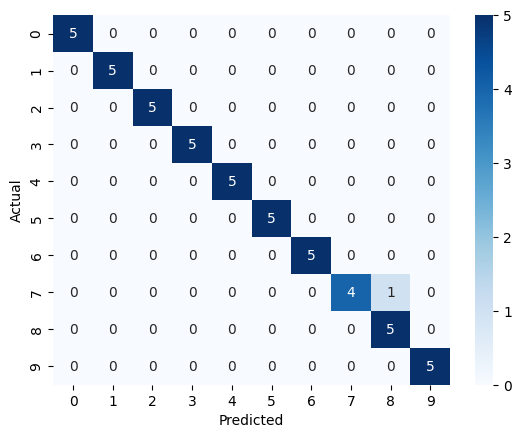

In [ ]:
cm = confusion_matrix(test_batches.classes,y_pred)
classes = ['0','1','2','3','4','5','6','7','8','9']
sns.heatmap(cm,annot = True,xticklabels=classes,yticklabels = classes,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
model.save("/content/drive/MyDrive/Problems/CNN/mobile_net_transfer_learning.h5")

### Inferencing

In [33]:
model = load_model("/content/drive/MyDrive/Problems/CNN/mobile_net_transfer_learning.h5")

In [34]:
def preprocess_image(img_path):
  load_img = image.load_img(img_path,target_size = (224,224))
  img_arr  = image.img_to_array(load_img)
  img_arr = np.expand_dims(img_arr,axis = 0)
  # img_arr = img_arr/255
  return tf.keras.applications.mobilenet.preprocess_input(img_arr)

In [38]:
get_data = preprocess_image("/content/drive/MyDrive/Problems/CNN/Data/Sign-Language-Digits-Dataset/test/5/IMG_1317.JPG")
predict_data = model.predict(get_data)
print(f"The digit is {np.argmax(predict_data)} predicted with probability of {predict_data[0][np.argmax(predict_data)]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
The digit is 5 predicted with probability of 0.9999574422836304


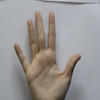

In [39]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/Data/Sign-Language-Digits-Dataset/test/5/IMG_1317.JPG",width = 300,height = 200)

#### test 1

In [59]:
get_data = preprocess_image("/content/drive/MyDrive/Problems/CNN/Data/image_bright.jpg")
predict_data = model.predict(get_data)
print(f"The digit is {np.argmax(predict_data)} predicted with probability of {predict_data[0][np.argmax(predict_data)]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
The digit is 5 predicted with probability of 0.9991111159324646


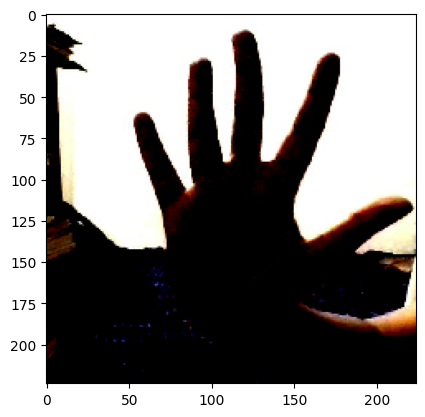

In [60]:
plt.imshow(get_data.reshape((224,224,3)))

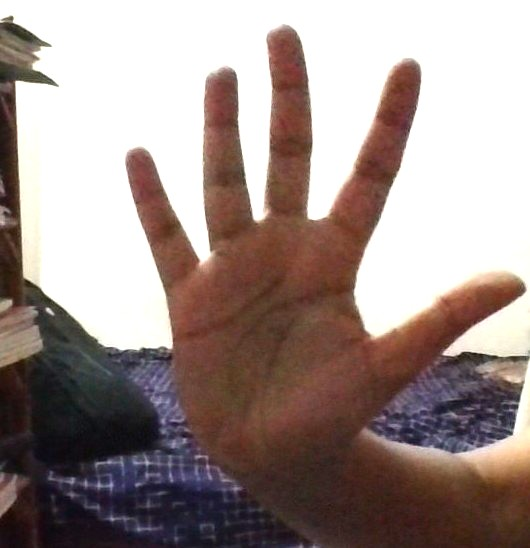

In [61]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/Data/image_bright.jpg",width = 300,height = 200)

#### test 2

In [66]:
get_data = preprocess_image("/content/drive/MyDrive/Problems/CNN/Data/image_low.jpg")
predict_data = model.predict(get_data)
print(f"The digit is {np.argmax(predict_data)} predicted with probability of {predict_data[0][np.argmax(predict_data)]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
The digit is 5 predicted with probability of 0.9998186230659485


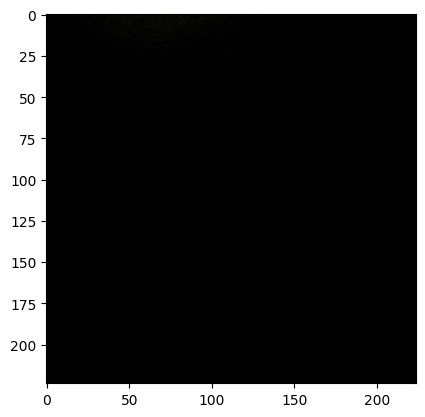

In [67]:
plt.imshow(get_data.reshape((224,224,3)))

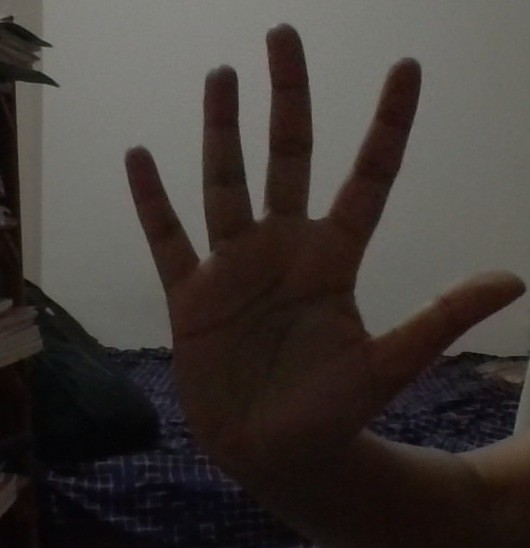

In [68]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/Data/image_low.jpg",width = 300,height = 200)

### Test 3

In [69]:
get_data = preprocess_image("/content/drive/MyDrive/Problems/CNN/Data/test_img.jpg")
predict_data = model.predict(get_data)
print(f"The digit is {np.argmax(predict_data)} predicted with probability of {predict_data[0][np.argmax(predict_data)]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
The digit is 7 predicted with probability of 0.6373382210731506


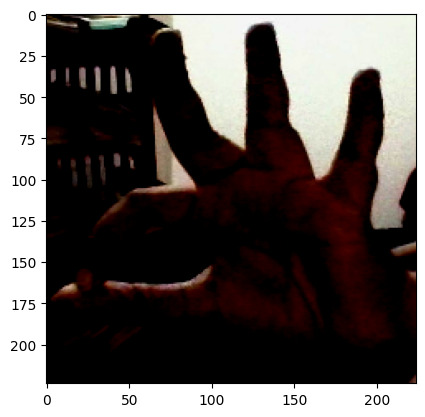

In [71]:
plt.imshow(get_data.reshape((224,224,3)))

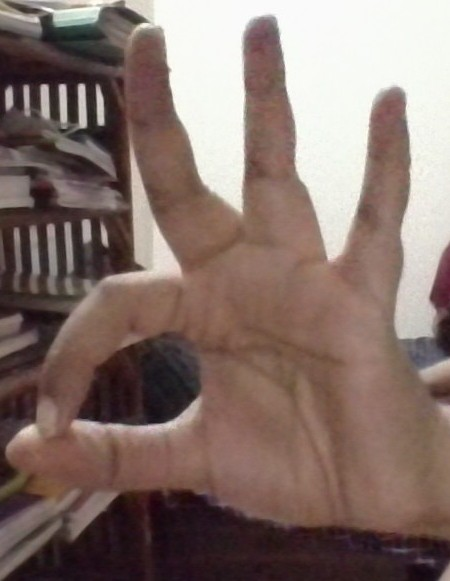

In [70]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/Data/test_img.jpg",width = 300,height = 200)

In [76]:
get_data = preprocess_image("/content/drive/MyDrive/Problems/CNN/test_img_2.jpg")
predict_data = model.predict(get_data)
print(f"The digit is {np.argmax(predict_data)} predicted with probability of {predict_data[0][np.argmax(predict_data)]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
The digit is 0 predicted with probability of 1.0


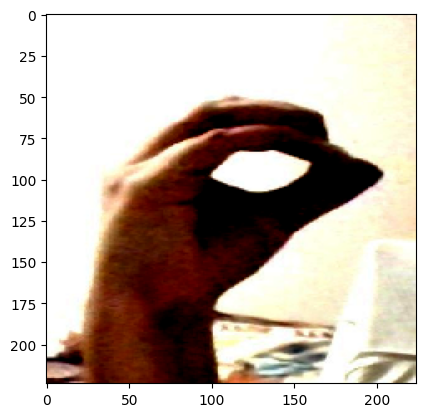

In [77]:
plt.imshow(get_data.reshape((224,224,3)))

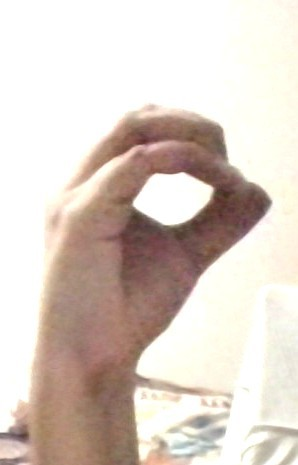

In [78]:
from IPython.display import Image
Image("/content/drive/MyDrive/Problems/CNN/test_img_2.jpg",width = 224,height = 224)